In [1]:
import matplotlib.pyplot as plt
import pickle
import torch
from math import ceil
from typing import Dict, Any

In [2]:
with open("metrics_sam3.pkl", "rb") as f:
    metrics_sam3 = pickle.load(f)

with open("mllms_metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

with open("metrics_segface.pkl", "rb") as f:
    metrics_segface = pickle.load(f)

all_metrics = metrics
for metric_name, metric_records in all_metrics.items():
    all_metrics[metric_name]["sam3"] = metrics_sam3[metric_name]["sam3"]

for metric_name, metric_records in all_metrics.items():
    all_metrics[metric_name]["segface"] = metrics_segface[metric_name]["segface"]

In [3]:
metric_names = list(all_metrics.keys())
model_names = list(all_metrics["f1"].keys())
print(metric_names)
print(model_names)
mllms = ["gemini-pro", "gemini-pro-shuffled", "gemini", "gpt"]

['f1', 'iou', 'dice']
['gemini-pro', 'gemini-pro-shuffled', 'gemini', 'gpt', 'sam3', 'segface']


In [4]:
model_code_names = {
    "gemini-pro": "gmn3",
    "gemini-pro-shuffled": "gmn3-shuffled",
    "gemini": "gmn2.5",
    "gpt": "gpti",
    "sam3": "sam3",
    "segface": "segface",
}

In [6]:
def get_stats(
    all_metrics: Dict[str, Any], model: str, metric_name: str
) -> Dict[str, Any]:
    result = {"model": model, "metric_name": metric_name}
    metric = all_metrics[metric_name][model]  # shape: (num_images, num_attempts)
    p1_values = metric[:, 0]
    p1_value_std, p1_value_mean = torch.std_mean(p1_values)
    result["p1_std"] = p1_value_std
    result["p1_mean"] = p1_value_mean
    if model in mllms:
        p3_values = metric[:, :3].max(dim=1).values
        p3_value_std, p3_value_mean = torch.std_mean(p3_values)
        result["p3_std"] = p3_value_std
        result["p3_mean"] = p3_value_mean
        p5_values = metric[:, :5].max(dim=1).values
        p5_value_std, p5_value_mean = torch.std_mean(p5_values)
        result["p5_std"] = p5_value_std
        result["p5_mean"] = p5_value_mean
    else:
        result["p3_std"] = None
        result["p3_mean"] = None
        result["p5_std"] = None
        result["p5_mean"] = None
    return result

In [7]:
stats = {}

for metric_name in metric_names:
    stats[metric_name] = {}
    for model in model_names:
        stats[metric_name][model] = get_stats(all_metrics, model, metric_name)

In [10]:
def draw_bar_chart(stat_to_draw: Dict[str, Any], metric_name: str):
    models = list(stat_to_draw.keys())
    x_positions = list(range(len(models)))
    bar_width = 0.25  # Make bar width smaller for 3 bars per group

    p1_x, p1_means, p1_stds = [], [], []
    p3_x, p3_means, p3_stds = [], [], []
    p5_x, p5_means, p5_stds = [], [], []

    for idx, model in enumerate(models):
        result = stat_to_draw[model]
        has_p3 = result["p3_mean"] is not None
        has_p5 = result["p5_mean"] is not None

        # Determine offsets for bar groups (centered around position)
        # If there's p3 and p5, positions will be -bar, 0, +bar; else, single at x
        if has_p3 and has_p5:
            p1_x.append(x_positions[idx] - bar_width)
            p3_x.append(x_positions[idx])
            p5_x.append(x_positions[idx] + bar_width)
        elif has_p3:  # This implicitly means p5 may be absent (should not happen given your stats, but for completeness)
            p1_x.append(x_positions[idx] - bar_width / 2)
            p3_x.append(x_positions[idx] + bar_width / 2)
        else:
            p1_x.append(x_positions[idx])

        p1_means.append(result["p1_mean"].item())
        p1_stds.append(result["p1_std"].item())

        if has_p3:
            p3_means.append(result["p3_mean"].item())
            p3_stds.append(result["p3_std"].item())
        if has_p5:
            p5_means.append(result["p5_mean"].item())
            p5_stds.append(result["p5_std"].item())

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        p1_x, p1_means, bar_width, yerr=p1_stds, capsize=5, label="P=1", color="#1f77b4"
    )
    if p3_means:
        ax.bar(
            p3_x,
            p3_means,
            bar_width,
            yerr=p3_stds,
            capsize=5,
            label="P=3",
            color="#ff7f0e",
        )
    if p5_means:
        ax.bar(
            p5_x,
            p5_means,
            bar_width,
            yerr=p5_stds,
            capsize=5,
            label="P=5",
            color="#2ca02c",
        )

    values_with_error = [mean + std for mean, std in zip(p1_means, p1_stds)]
    if p3_means:
        values_with_error.extend(mean + std for mean, std in zip(p3_means, p3_stds))
    if p5_means:
        values_with_error.extend(mean + std for mean, std in zip(p5_means, p5_stds))
    if values_with_error:
        max_ylim = ceil(max(values_with_error) / 0.1) * 0.1
        ax.set_ylim(0, max_ylim)

    ax.set_xticks(x_positions)
    code_names = [model_code_names[model] for model in models]
    ax.set_xticklabels(code_names, ha="center")
    ax.set_ylabel(f"{metric_name}")
    ax.set_title(f"{metric_name} with Std")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

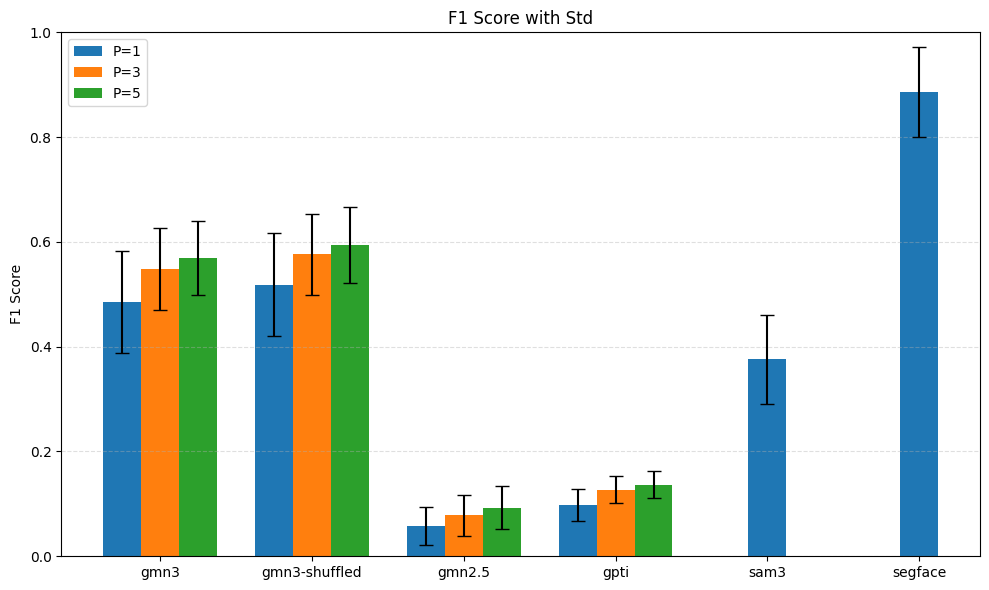

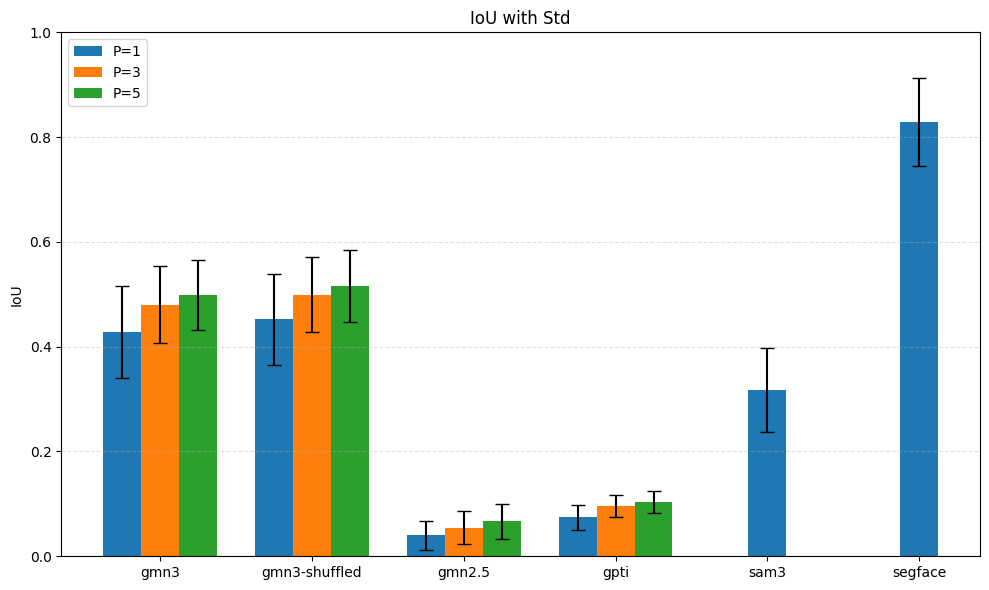

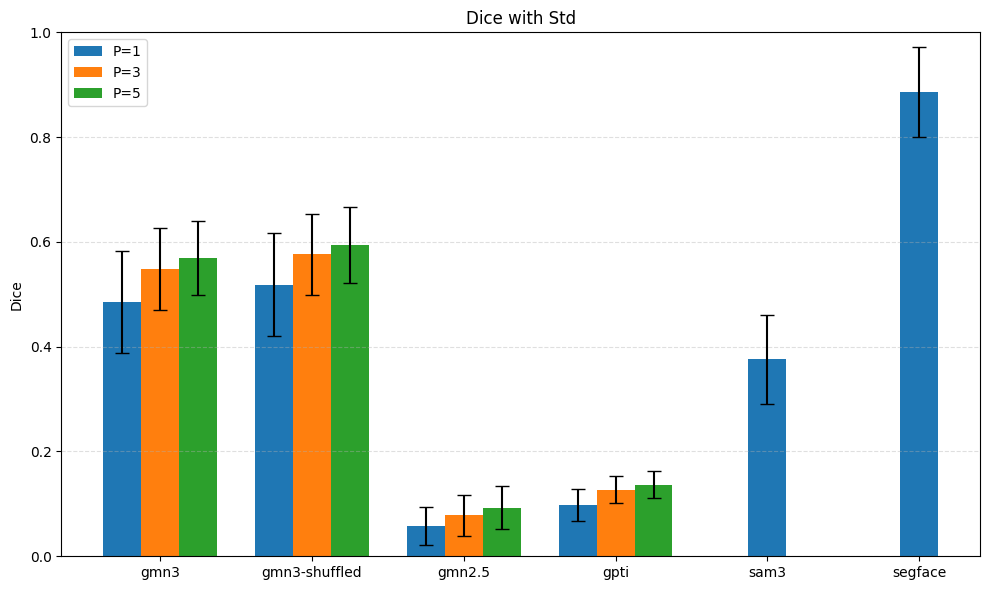

In [11]:
draw_bar_chart(stats["f1"], "F1 Score")
draw_bar_chart(stats["iou"], "IoU")
draw_bar_chart(stats["dice"], "Dice")